# ДЗ №01: кодирование-кодирование-кодирование
TOTAL Σ = 33 балла  
BONUS Σ = 16.5 балла  
MAX Σ = 49.5 балла

---

In [1]:
from codinglab import (
    PandasLogger,
    PrefixEncoderDecoder,
    SourceChar,
    ProbabilisticSender,
)
from collections import OrderedDict
from enum import Enum
import matplotlib.pyplot as plt

### Инструкции по сдаче ДЗ:
1. Все взаимодействие происходит через hwproj: там надо зарегистрироваться и подать заявку на [курс](https://hwproj.ru/courses/50080)
2. Ознакомьтесь с условиями задач; Если есть вопросы, их можно задать через специальную вкладку на hwproj
3. Теоретическая часть сдаётся либо в виде отдельного заТеХанного PDF-файла (загружается на hwproj) либо вместе с практической частью в этом ноутбуке в формате markdown (см. дальше). 
4. Сдавать практическую часть с программированием можно двумя способами:
   - Первый способ (правильный, и даёт бонусные баллы):
        1. Сделать закрытый форк репозитория, добавить меня ([desiment](github.com/Desiment)) коллаборатором
        2. Сделать под каждую из двух практических задач свою ветку, добавить реализацию классов, написать докстринги, посмотреть что обновлённая документация собирается; Не забудьте написать тесты (используйте pytest), добавить подсказки типов, пройтись pre-commit-ом (например  через ``poetry run pre-commit run --all-files``) и соблюдайте [стандартные практики](https://www.conventionalcommits.org/en/v1.0.0/) при ведении репозитория
        5. В Jupyter-ноутбуке добавить необходимые импорты и сделать в нём части не связанные с реализацией
    - Если от предыдущего пункта вы упали в обморок, уронили митболы и заляпали свитшот смузи, то вам сюда (с) dluciv.  
      Второй способ это просто заполнить этот ноутбук локально, или в Google Collab (во втором случае может потребоваться пошаманить с ``!``-командами, в частности клонировать репозиторий);
        1. Если вы делаете локально, сам ноутбук загружается на hwproj, в соответствующей вкладке 
        2. Если вы делаете на Google Collab, на hwproj прикладываете ссылку; *Убедитесь что данные, которые вы использовали, доступны для скачивания*
    - При выборе первого способа количество баллов за практическую часть удваивается (т.е. вместо 16.5 баллов вы можете получить 33 балла). Если вы выбрали первый способ выполнения практических заданий (считается что это с момента как я стал коллаборатором), то обе задачи надо сдавать так - назад пути нет.
5. GLHF

## Блок I: теория
MAX Σ = 16.5 баллов


### Задача 1. И снова алгоритм Хаффмана
8 баллов

---

Пусть $\mathcal{A} = \{a_1, \ldots, a_r\}$ — алфавит источника, с вероятностями символов $\mathcal{P} = \{p_1, \ldots, p_n\}$, $\Sigma = \{0, 1\}$ — алфавит кодировщика. Для произвольного однозначно декодируемого кода $f \colon \mathcal{A} \to \Sigma^*$ за $C^{f}$ обозначим набор $\{f(a_1), \ldots, f(a_r)\}$. Напомним что средней длинной кода $f$ называется величина:
$$ L(C^f) = \sum_{i = 1}^{r} p_i |C_i^f| $$

**Задачи**
1. *(1 балл)* Пусть $f$ — некоторый однозначно-декодируемый код. Покажите что существует префиксный код $g$ такой, что $L(C^{g}) = L(C^{f})$
2. *(1 балл)* Пусть $f$ — некоторый префиксный код, $x, y \in \mathcal{A}$ — два символа, имеющие наименьшие вероятности $p_x$ и $p_y$ (т.е. для любого другого символа из алфавита $a \in \mathcal{A}, a \neq x, a \neq y$ его вероятность  $p_a \geq \max(p_x, p_y)$.
Докажите что существует префиксный код $g$ такой, что:
    - код $g$ не хуже кода $f$: $L(C^{g}) \leq L(C^{f})$;
    - в коде $g$ кодовые слова символов $x$ и $y$ имеют одинаковую длину.
3. *(1 балл)* Пусть $x, y \in \mathcal{A}$ два символа с наименьшими вероятностями $p_x, p_y$. Рассмотрим алфавит $\mathcal{A}'$ получаемый из алфавита $\mathcal{A}$ заменой символов $x$ и $y$ на некоторый новый символ $z$, вероятность которого равна $p_z = p_x + p_y$. Пусть $f'_1, f'_2$ — два префиксных кода для алфавита $\mathcal{A}'$. Определим префиксные коды для алфавита $\mathcal{A}$ следующим образом:
$$ f_1(a) = \begin{cases} f_1'(a) & a \neq x, y \\ f_1'(z)0 & a = x \\ f_1'(z)1 & a = y \end{cases} \qquad f_2(a) = \begin{cases} f_2'(a) & a \neq x, y \\ f_2'(z)0 & a = x \\ f_2'(z)1 & a = y \end{cases}$$
Докажите что если $L(C^{f_1'}) \leq L(C^{f_2'})$, то и $L(C^{f_1}) \leq L(C^{f_2})$
4. *(2 балла)*. Пусть $C^H$ обозначает код Хаффмана для алфавита $\mathcal{A}$. Докажите что $L(C^H) \leq L(C^f)$ для любого однозначно-декодируемого кода $f$.
5. *(3 балла)*. Пусть $C^H_n$ обозначает код Хаффмана для алфавита  $\mathcal{A}^n$ (алфавита состоящего из слов длины $n$). Положим что для слова $a_{i_1}\ldots a_{i_n}$ его вероятность равна $p_{i_1}\ldots p_{i_n}$. Докажите что:
$$\lim_{n \to +\infty}\frac{L(C^{H}_n)}{n} =\mathrm{H}_2(p_1, \ldots, p_n)$$

### Задача 2. Энтропия для серии зависимых случайных величин
8.5 баллов

---

Рассмотрим последовательность дискретных случайных величин $\xi_1, \ldots, \xi_n$ со значениями из множества $\mathcal{X} = \set{x_1, \ldots, x_r}$, такую что:
1. Все они имеют одинаковое распределение: $\mathbb P(\xi_k = x_j) = \pi_j \quad \forall i = 1, \ldots, n$;
2. Они обладают *марковским свойством*: для любых $x_{i_1}, \ldots x_{i_k} \in \mathcal{X};\, k = 1, \ldots n$, таких, что условные вероятности ниже имеют смысл, выполнено:
$$\mathbb{P}(\xi_k = x_{i_k} | \xi_{k - 1} = x_{i_{k-1}}, \ldots, \xi_{1} = x_{i_1}) = \mathbb{P}(\xi_k = x_{i_k} | \xi_{k - 1} = x_{i_{k-1}}) $$
3. Выполнено свойство стационарности:
$$\mathbb{P}(\xi_{1} = x_{i_1}, \ldots, \xi_{k} = x_{i_k}) = \mathbb{P}(\xi_{t+1} = x_{i_1}, \ldots, \xi_{t+k} = x_{i_k}) \quad \text{для любых $x_{i_1}, \ldots x_{i_k} \in \mathcal{X};\, k = 1, \ldots n;\, t = 1, \ldots, n - k$}$$


**Задачи**
1. *(1 балл)* Обозначим $p_{j \to i} = \mathbb{P}(\xi_{2} = x_i | \xi_{1} = x_j)$ — так называемые *вероятности переходов*. Предположим что все вероятности переходов  положительны: $p_{j \to i} > 0$ для всех $i, j = 1, \ldots r$. Докажите что тогда вероятности значений также положительны: $\pi_j > 0$ для всех $j = 1, \ldots, r$
2. *(1.5 балла)* Рассмотрим матрицу:
   $$ P  = \begin{pmatrix}p_{1 \to 1} & p_{1 \to 2} & \cdots & p_{1 \to r} \\
                     p_{2 \to 1} &   \ddots    & \vdots & p_{2 \to r} \\
                        \vdots   &   \cdots    & \ddots &  \vdots     \\
                     p_{r \to 1} & p_{r \to 2} & \cdots & p_{r \to r}
         \end{pmatrix}$$
   Докажите что вектор-строчка $\pi = (\pi_1, \ldots, \pi_r)$ является собственным вектором матрицы $P$ (т.е. $\pi P = \lambda\pi, \lambda \in \mathbb{R}$). Найдите соответствующее вектору $\pi$ собственное число $\lambda$.  
3. *(1.5 балла)* Покажите что условие 3 не следует из условий 1-2
4. *(1.5 балла)* Выразите вероятность $\mathbb{P}(\xi_2 = x_j, \xi_1 = x_i)$  в терминах матрицы $P$ и вектора $\pi$.
5. *(1.5 балла)* Выразите вероятность $\mathbb{P}(\xi_k = x_j | \xi_1 = x_i)$ в терминах матрицы $P$.
6. *(1.5 балла)* Обозначим за $T = \mathrm{diag}(\pi_1, \ldots, \pi_r) \cdot P$. Докажите что:
$$\mathrm{H}_2(T) \coloneqq  -\sum_{i = 1}^{r}\sum_{j = 1}^{r} T_{ij} \log_2 T_{ij} = \frac{1}{n-1}\mathrm{H}_2(\xi_{1}, \ldots, \xi_{n}) + \frac{n-2}{n-1} \cdot \mathrm{H}_2(\xi_1)$$



**РЕШЕНИЕ**:
Вы можете изложить свое решение тут, либо загрузить заTeXанные решения в формате PDF на hwproj

## Блок II: Кодирование
MAX Σ = 16.5 баллов  
BONUS Σ = 16.5 баллов

---

### Задача I: Код Шеннона-Фано-Элиаса

В классических алгоритмах построения оптимальных префиксных кодов (например, в алгоритме Хаффмана) порядок кодовых слов в выходном потоке не имеет значения — мы просто стремимся к минимальной длине. Однако в некоторых приложениях, таких как посимвольное сжатие с последующим поиском или криптография, требуется, чтобы кодовые слова располагались в строго лексикографическом порядке (то есть код символа, идущего раньше в алфавите, был лексикографически меньше кода следующего символа). Алгоритм Шеннона-Фано-Элиаса является модификацией алгоритма Шеннона и позволяет решать эту задачу

**Описание алгоритма**  
Пусть алфавит состоит из символов $\mathcal{X} = \{1, 2, \dots, m\}$ (отождествляем символы с их номерами в лексикографическом порядке) с известными вероятностями $p(x) > 0$. Для каждого символа $x$ вычисляется модифицированная функция распределения
$$\overline{F}(x) = \sum_{a < x} p(a) + \frac{1}{2}p(x)$$
которая представляет собой середину "ступеньки", соответствующей символу $x$ на графике функции распределения. Это число лежит в интервале $[0, 1]$. Затем мы берем двоичную запись числа $\overline{F}(x)$ и округляем (отбрасываем дробную часть) до $l(x)$ бит, где $l(x) = -\lceil \log_2 (p(x)) \rceil + 1$. 


**Задачи:**

1. *(3 балла)* Реализуйте алгоритм Шеннона-Фано-Элиаса и закодируйте им случайное сообщение длины $1000$ на алфавите $\mathcal{A} = \{a, b, c, d, e\}$ с вероятностями символов $\{0.75, 0.025, 0.1, 0.05, 0.075 \}$; вычислите энтропию источника, среднюю длину получившегося кода и эффективность кода; В качестве порядка символов возьмите стандартный лексикографический порядок
2. *(2 балла)* Сравните избыточность получившегося кода по сравнению с кодом Шеннона и кодом Хаффмана. Сравните получившееся фактически размеры закодированных текстов.

**ВАШЕ РЕШЕНИЕ И МЫСЛИ ТУТ**

In [2]:
class BinaryAlphabet(str, Enum):
    zero: "0"
    one: "1"


class ShannonFanoEliasBinaryCoder(PrefixEncoderDecoder[SourceChar, BinaryAlphabet]):
    """
    Shannon-Fano-Elias Coder for prefix codes.

    This coder implements the Shannon-Fano-Elias coding algorithm, which
    constructs prefix codes based on the cumulative distribution function.
    For each symbol x with probability p(x), the code length is:
    l(x) = -⌈log₂(p(x))⌉ + 1
    The code is the binary representation of the modified cumulative
    probability F̄(x) = Σ_{a<x} p(a) + p(x)/2, truncated to l(x) bits.

    Attributes:
        _probabilities: Ordered dictionary mapping source symbols to their probabilities
        _cumulative_probs: Dictionary mapping symbols to their cumulative probabilities
        _modified_cumulative: Dictionary mapping symbols to their modified cumulative F̄(x)
    """

    def __init__(
        self,
        probabilities: OrderedDict[SourceChar, float],
    ) -> None:
        """
        Initialize the Shannon-Fano-Elias encoder with symbol probabilities.

        Args:
            probabilities: Ordered dictionary mapping source symbols to their
                           probabilities (must sum to 1.0). The order determines
                           the cumulative probability calculation.

        Raises:
            ValueError: If probabilities don't sum to approximately 1.0
                       or if any probability is non-positive
        """
        # :D
        ...

    def _build_prefix_code_tree(self) -> None:
        # :D
        ...

    @property
    def expected_code_length(self) -> float:
        """
        Calculate the expected code length.

        Returns:
            Expected number of channel symbols per source symbol,
            weighted by symbol probabilities
        """
        # :D
        ...

    @property
    def entropy(self) -> float:
        """
        Calculate the Shannon entropy of the source.

        Returns:
            Shannon entropy in bits (for binary channel)
        """
        # :D
        ...

    @property
    def coding_efficiency(self) -> float:
        """
        Calculate the coding efficiency.

        Returns:
            Ratio of entropy to expected code length,
            representing how close the code is to optimal
        """
        # :D
        ...

In [3]:
logger = PandasLogger()
probabilities = {"a": 0.75, "b": 0.025, "c": 0.1, "d": 0.05, "e": 0.075}

# Create encoder with binary channel alphabet
encoder = ...  # :D

# Probabilitstic sender
# We will send one symbol per message
sender = ProbabilisticSender(
    encoder=encoder,
    probabilities=probabilities,
    message_length_range=(1, 1),
    logger=logger,
    seed=42,
)


### Create and run experiment

# print("Running experiment with transmitting 1000 symbols ...")
# runner = ExperimentRunner(sender, NoiselessChannel(logger=logger), TrackingReceiver(encoder, logger=logger))
# result = runner.run(num_messages=1000)
# shannon_ellias_df = logger.dataframe
# shannon_ellias_df.head()

In [4]:
# Вычислите энтропию источника, среднюю длину получившегося кода и эффективность кода
# :D

In [5]:
# Сравните избыточность получившегося кода по сравнению с кодом Шенонна и кодом Хаффмана.
# :D

In [6]:
# Сравните получившеся фактически размеры закодированных текстов.
# :D

### Задача II: И снова алгоритм Хаффмана
11.5 баллов

---

Изложенная в задаче 1.5 из блока I техника не имеет какого-то названия, но весьма примечательна. Дальше будем называть её *кодом Хаффмана для $n$-грамм*. Можно грубо прикинуть что если

$$\lim_{n \to +\infty}\frac{L(C^{H}_n)}{n} =\mathrm{H}_2(p_1, \ldots, p_n),$$

то при кодировании текста длины $\ell$ обычным кодом Хаффмана, то, в среднем, длина $S$ текста в закодированном виде будет лежать в интервале (подумайте почему так):

$$\ell \cdot \mathrm{H}_2(p_1, \ldots, p_n) \leq S \leq \ell \cdot (\mathrm{H}_2(p_1, \ldots, p_n) + 1) $$

В то же время, если текст разбивается на блоки длины $n$, то сообщение, состоящее из блоков, будет иметь длину $\ell / n$ и значит, длина текста в закодированном виде будет лежать где-то в интервале:

$$\frac{\ell}{n} \cdot n\mathrm{H}_2(p_1, \ldots, p_n) \leq S \leq \frac{\ell}{n} \cdot (n\mathrm{H}_2(p_1, \ldots, p_n) + 1) $$

Нижняя граница такая же, как и в случае обычного кодирования по Хаффману, а вот верхняя прижалась сильнее. Казалось бы, вывод очевиден: чем больше $n$, тем лучше. Однако как мы скоро убедимся, это не так. Тем не менее гипотеза, что с ростом $n$ растет эффективность алгоритма, будем считать основной

---

Проблема связанная с тем что
$$\lim_{n \to +\infty}\frac{L(C^{H}_n)}{n} =\mathrm{H}_2(p_1, \ldots, p_n)$$
состоит в том что равенство носит только асимптотический характер. Насколько окажутся верными грубые прикидки может показать только эксперимент, который и предлагается провести в этой задаче.

Эксперимент будет состоять из двух этапов:
1.  **Эксперимент на синтетических данных.**
    *   Генерация нескольких последовательностей символов с заранее заданными распределениями вероятностей.
    *   Для каждой последовательности и для каждого значения длины блока:
        *   Построить код Хаффмана по частотам блоков.
        *   Выполнить кодирование.
        *   Рассчитать метрики работы алгоритма.
    *   Цель эксперимента — проверить теоретические положения в контролируемых условиях.

2.  **Эксперимент на реальных данных.**
    *   Выбор нескольких файлов-репрезентантов различных типов данных (например текст на естественном языке или файл изображения).
    *   Расчет метрик работы алгоритма. Оценку вероятностей символов (n-грамм) производить по эмпирическим частотам.
    *   Цель эксперимента — оценить практическую применимость подхода на данных со сложной структурой и сопоставить полученные результаты с выводами из "стерильных" условий синтетического эксперимента.

**Задачи**

1. *(2 балла). Подготовка к экспериментам*.
   - Реализуйте код Хаффмана для n-грам (алфавит кодера считать бинарным). Вы можете сделать либо два класса (разделить кодер и декодер), либо один общий класс; в обоих случаях ваша реализация должна следовать протоколам ``Encoder`` и ``Decoder`` (см. документацию). В случае если длина кодируемого текста не кратна $n$, текст нужно дополнить специальным символом до длины кратной $n$.
    - Определите набор метрик, которые будут сниматься в результате работы алгоритма, и набор переменных, влияние которых будет исследоваться. Обоснуйте свой выбор.
2. *(2 балла). Подготовка валидационных данных*.
    - Определите количество наборов, число символов и их распределение в каждом наборе, размер набора. Обоснуйте выбор (вам может потребоваться предварительный эксперимент; если так, его также стоит включить в решение).
      Используйте класс ``ProbabilisticSender``, чтобы сгенерировать предложенные наборы; зафиксируйте seed генерации.
3. *(3 балла). Анализ на синтетических данных*.
    - Проведите эксперименты на сгенерированных наборах, варьируя выбранные в п.1 переменные.
    - Постройте графики зависимости метрик от переменных.
    - Проанализируйте полученные результаты. Сравните с теоретическими ожиданиями.
4. *(1.5 балла). Подготовка реальных данных*
    - Определите набор реальных данных для анализа. Обоснуйте выбор: чем интересен именно этот набор, какие зависимости вы ожидаете увидеть.
    - Подготовьте данные к использованию (при необходимости).
5. *(3 балла). Анализ на реальных данных*
    - Примените реализованный алгоритм к реальным данным.
    - Сравните результаты с синтетическими экспериментами.
    - Оцените эффективность сжатия: достигнутая степень сжатия, скорость работы, влияние размера блока.
    - Сделайте выводы

**ВАШЕ РЕШЕНИЕ И МЫСЛИ ТУТ**

In [7]:
from codinglab import SourceChar, ChannelChar, PrefixCodeTree, TreeNode, PrefixEncoderDecoder
from typing import Sequence, Optional, Dict, List
from dataclasses import dataclass
from enum import Enum
import math

import heapq
from itertools import product
from collections import OrderedDict

In [8]:
import heapq


class BinaryAlphabet(str, Enum):
    zero: "0"
    one: "1"


@dataclass(kw_only=True)
class HuffmanNode(TreeNode[ChannelChar, SourceChar]):
    """Node in the Huffman tree during construction."""

    freq: float

    def __lt__(self, other: "HuffmanNode[ChannelChar, SourceChar]") -> bool:
        return self.freq < other.freq


class HuffmanNGramEncoder(PrefixEncoderDecoder[SourceChar, BinaryAlphabet]):
    """
    Huffman encoder-decoder for optimal prefix codes.

    This encoder implements the Huffman coding algorithm, which constructs
    an optimal prefix code for a given set of symbol frequencies. More
    frequent symbols get shorter codes, minimizing the expected code length.

    Attributes:
        _frequencies: Dictionary mapping source symbols to their frequencies
    """

    def __init__(self, n: int, frequencies: Dict[SourceChar, float]) -> None:
        """
        Initialize the Huffman encoder with symbol frequencies.

        Args:
            n: length of n-grams
            frequencies: Dictionary mapping source symbols to their
                        frequencies (or probabilities)

        Raises:
            ValueError: If frequencies don't match source alphabet,
                       or if channel alphabet is not binary
        """
        
        """Dictionary mapping source symbols to their frequencies."""

        self.len_ngram = n
        self._ngram_freq : Dict[SourceChar, float] = {}
        self._base_freq : Dict[SourceChar, float] = frequencies

        for ngram in product(frequencies.keys(), repeat=n):
            str_ngram = "".join(ngram)
            self._ngram_freq[str_ngram] = 1.0
            for symbol in ngram:
                self._ngram_freq[str_ngram] *= frequencies[symbol]


        for i in range(1, n):
            for ngram in product(frequencies.keys(), repeat=i):
                str_ngram = "".join(ngram) + "#" * (n - i)
                self._ngram_freq[str_ngram] = 1.0
                for symbol in ngram:
                    self._ngram_freq[str_ngram] *= frequencies[symbol]
                self._ngram_freq[str_ngram] *= 10e-9**(n-i)

        super().__init__(self._ngram_freq.keys(), ["0", "1"])

    def _build_prefix_code_tree(self) -> None:
        """Build Huffman tree using the priority queue algorithm."""
        # Create leaf nodes for all symbols
        heap = []
        for symbol, freq in self._ngram_freq.items():
            heapq.heappush(heap, HuffmanNode(freq=freq, value=symbol))

        # Build Huffman tree
        while len(heap) > 1:
            left = heapq.heappop(heap)
            right = heapq.heappop(heap)
            parent = HuffmanNode(
                freq=left.freq + right.freq,
                value=None,
                children={"0": left, "1": right},
            )
            heapq.heappush(heap, parent)

        # Convert Huffman tree to prefix code tree
        root_huffman = heap[0] if heap else None
        self._tree = PrefixCodeTree(root_huffman)
        self._build_table_from_tree()

    def _huffman_to_prefix_tree(
        self, huffman_node: Optional[HuffmanNode]
    ) -> PrefixCodeTree[BinaryAlphabet, SourceChar]:
        """Convert Huffman tree to prefix code tree."""
        prefix_tree = PrefixCodeTree()

        def build_tree(
            current_huffman: HuffmanNode, 
            current_prefix: List[BinaryAlphabet]
        ) -> None:

            if current_huffman.value is not None:
                prefix_tree.insert_code(current_prefix, current_huffman.value)
            else:
                if "0" in current_huffman.children:
                    build_tree(
                        current_huffman.children["0"],
                        current_prefix + [self._channel_alphabet[0]],
                    )
                if "1" in current_huffman.children:
                    build_tree(
                        current_huffman.children["1"],
                        current_prefix + [self._channel_alphabet[1]],
                    )

        if huffman_node:
            build_tree(huffman_node, [])

        return prefix_tree
    

    def encode(self, message: Sequence[SourceChar]) -> List[BinaryAlphabet]:
        """Encode a message using the prefix code."""
        code = []
        message += "#" * ((self.len_ngram - len(message) % self.len_ngram) % self.len_ngram)
        for symbol in range(0, len(message), self.len_ngram):
            ngram = "".join(message[symbol:symbol + self.len_ngram])
            if ngram not in self._code_table:
                raise ValueError(f"Symbol '{ngram}' not in code table")
            code.extend(self._code_table[ngram])
        return code
    
    def decode(self, encoded: Sequence[BinaryAlphabet]) -> List[SourceChar]:
        if self._tree is None:
            raise RuntimeError("Decoding tree not built")

        position = 0
        decoded = []
        encoded_list = list(encoded)

        while position < len(encoded_list):
            symbol, new_position = self._tree.decode(encoded_list, position)
            if symbol is None:
                raise ValueError(
                    f"Cannot decode sequence {encoded}. Processed to {position}"
                )
            decoded.append(symbol)
            position = new_position

        while decoded[-1][-1] == "#":
            decoded[-1] = decoded[-1][:-1]
            if not decoded[-1]:
                decoded.pop()

        return decoded
        

    @property
    def expected_code_length(self) -> float:
        """
        Calculate the expected code length.

        Returns:
            Expected number of channel symbols per source symbol,
            weighted by symbol frequencies
        """
        if not self._code_table:
            return 0.0

        total = 0.0
        for symbol, freq in self._ngram_freq.items():
            if symbol in self._code_table and "#" not in symbol:
                total += freq * len(self._code_table[symbol])
        return total / self.len_ngram

    @property
    def entropy(self) -> float:
        """
        Calculate the Shannon entropy of the source.

        Returns:
            Shannon entropy in bits (for binary channel)
        """
        h = 0.0
        for symbol, freq in self._ngram_freq.items():
            if freq > 0 and "#" not in symbol:
                h -= freq * math.log2(freq)
        return h / self.len_ngram

    @property
    def coding_efficiency(self) -> float:
        """
        Calculate the coding efficiency.

        Returns:
            Ratio of entropy to expected code length,
            representing how close the code is to optimal
        """
        expected_len = self.expected_code_length
        if expected_len == 0:
            return 0.0
        return self.entropy / expected_len

In [9]:
from codinglab import (
    FixedMessagesSender,
    ProbabilisticSender,
    NoiselessChannel,
    TrackingReceiver,
    ExperimentRunner,
)
from codinglab import PandasLogger

In [10]:
logger = PandasLogger()
probabilities = {"A": 0.1, "B": 0.2, "C": 0.2, "D": 0.4, "E": 0.1}

n = 2

# Create ehncoder with binary channel alphabet
encoder = HuffmanNGramEncoder(n=n, frequencies=probabilities)
print(encoder.entropy)
print(encoder.expected_code_length)

# Probabilitstic sender
sender = ProbabilisticSender(
    encoder=encoder,
    probabilities=probabilities,
    message_length_range=(10, 10),
    logger=logger,
    seed=42,
)
# Create channel
channel = NoiselessChannel(logger=logger)
# Create tracking receiver
receiver = TrackingReceiver(encoder, logger=logger)

print("Running experiment with 1000 messages...")
# Create and run experiment
runner = ExperimentRunner(sender, channel, receiver)
result = runner.run(num_messages=1000)

print("Experiment Results:")
print(f"   Duration: {result.duration:.4f} seconds")
print(f"   Total messages: {result.stats.total_messages}")
print(f"   Decoded: {result.stats.decoded_messages}")
print(f"   Messages with decoding errors: {result.stats.decode_errors}")
print(
    f"   Correctly decoded (decoded match original): {result.stats.successful_messages}"
)
print(f"   Total source symbols: {result.stats.total_source_symbols}")
print(f"   Total channel symbols: {result.stats.total_channel_symbols}")
print(f"   Average code length: {(result.stats.average_code_len / n):.2f}")
print(f"   Avg. processing time: {result.stats.avg_message_time:.6f} s/msg")
logger.dataframe.head(20)

2.1219280948873624
2.165000000000001
Running experiment with 1000 messages...
Experiment Results:
   Duration: 0.0276 seconds
   Total messages: 1000
   Decoded: 1000
   Messages with decoding errors: 0
   Correctly decoded (decoded match original): 1000
   Total source symbols: 5000
   Total channel symbols: 21421
   Average code length: 2.14
   Avg. processing time: 0.000015 s/msg


,timestamp,event,message_id,message_data
0,1.773058e+09,source_generated,0,ABBDDDACAB
1,1.773058e+09,transmitted,0,0110001110010101101100
2,1.773058e+09,received,0,0110001110010101101100
3,1.773058e+09,decoded,0,ABBDDDACAB
4,1.773058e+09,source_generated,1,DDDCCBDDBC
5,1.773058e+09,transmitted,1,001110110010010011
6,1.773058e+09,received,1,001110110010010011
7,1.773058e+09,decoded,1,DDDCCBDDBC
8,1.773058e+09,source_generated,2,BECAADDDDD
9,1.773058e+09,transmitted,2,10010101010110110000


### Задача 1

1. Заведем метрику $\frac{H_2(A) \cdot n}{L(C^H_n)} \in (0,1]$ --- чем ближе к $1$ тем круче

2. Переменные влияние которых будем исследовать: $|A|\in \{5, 10, 15, 26,33\}$ --- затестим эти алфавиты с равными вероятностями и со случайными вероятностями, а последние $2$ алфавита можно затестить на реальных данных $n \in \{1,2,3,4,5\}$ --- если брать $n > 6$ то $33^n > 10^{9}$ --- не супер быстро будет считаться на обычном компе, еще будем исследовать разные длины сообщения $l \in \{10, 50, 100, 200, 500, 1000\}$

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

def run_experiment(probs: dict) -> pd.DataFrame:

    res_dict = {}
    for N in range(1, 6):
        n_res_list = []
        for l in [10, 50, 100, 200, 500, 1000]:

            logger = PandasLogger()
            

            # Create ehncoder with binary channel alphabet
            encoder = HuffmanNGramEncoder(n=N, frequencies=probs)

            # Probabilitstic sender
            sender = ProbabilisticSender(
                encoder=encoder,
                probabilities=probs,
                message_length_range=(l, l),
                logger=logger,
                seed=42,
            )
            # Create channel
            channel = NoiselessChannel(logger=logger)
            # Create tracking receiver
            receiver = TrackingReceiver(encoder, logger=logger)

            # Create and run experiment
            runner = ExperimentRunner(sender, channel, receiver)
            result = runner.run(num_messages=1000)
            entropy = encoder.entropy
            n_res_list.append((entropy*N) / result.stats.average_code_len)
            
        res_dict[N] = n_res_list
            
    res_df = pd.DataFrame(res_dict, index=[10, 50, 100, 200, 500, 1000])
    print(res_df.head(50))
    return res_df


### Задачи 2-3

In [12]:
alpha = 5

probs = {"A": 1 / alpha, "B": 1 / alpha, "C": 1 / alpha, "D": 1 / alpha, "E": 1 / alpha}

encoder = HuffmanNGramEncoder(n=1, frequencies=probs)

print(f"Coding efficiency: {encoder.coding_efficiency}")
equal_probs_df_5 = run_experiment(probs)
print("Rows correspond to different message lengths, columns correspond to different n-gram lengths")

Coding efficiency: 0.967470039536401
             1         2         3         4         5
10    0.970260  0.976380  0.788341  0.687181  0.993678
50    0.966825  0.974895  0.958830  0.899865  0.993687
100   0.966922  0.975826  0.967099  0.991925  0.992790
200   0.967093  0.975955  0.987114  0.992078  0.993512
500   0.967678  0.975876  0.993236  0.991771  0.993062
1000  0.967464  0.975661  0.994238  0.991940  0.993135
Rows correspond to different message lengths, columns correspond to different n-gram lengths


In [13]:
n = 5

probabilities = np.random.dirichlet(np.ones(n))

keys = [chr(ord('A') + i) for i in range(n)]

probs = dict(zip(keys, probabilities))

encoder = HuffmanNGramEncoder(n=1, frequencies=probs)

print(f"Coding efficiency: {encoder.coding_efficiency}")
random_probs_df_5 = run_experiment(probs)
print("Rows correspond to different message lengths, columns correspond to different n-gram lengths")

Coding efficiency: 0.980421219628358
             1         2         3         4         5
10    0.973309  0.975328  0.512881  0.420486  0.990206
50    0.981923  0.985751  0.874881  0.759844  1.000836
100   0.980125  0.982794  0.894719  0.995874  0.996479
200   0.979344  0.982214  0.958711  0.995191  0.995897
500   0.979855  0.982858  0.978854  0.996089  0.996742
1000  0.980371  0.983588  0.982191  0.996382  0.997084
Rows correspond to different message lengths, columns correspond to different n-gram lengths


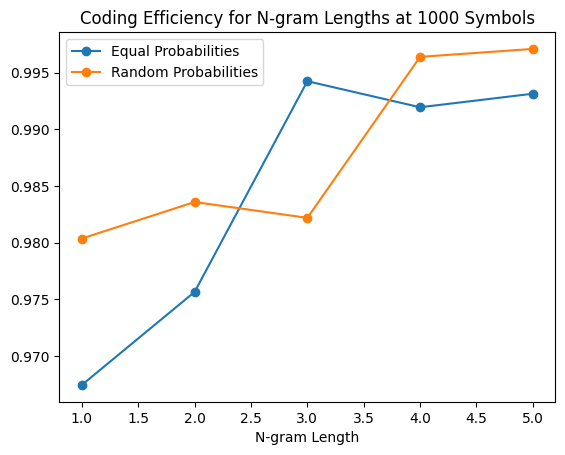

In [14]:
equal_1000_row_5symbols = equal_probs_df_5.loc[1000]
random_1000_row_5symbols = random_probs_df_5.loc[1000]

plt.plot(equal_1000_row_5symbols.index, equal_1000_row_5symbols.values, marker='o', label='Equal Probabilities')
plt.plot(random_1000_row_5symbols.index, random_1000_row_5symbols.values, marker='o', label='Random Probabilities')
plt.xlabel('N-gram Length')
plt.legend()
plt.title('Coding Efficiency for N-gram Lengths at 1000 Symbols')
None

In [15]:
alpha = 10

probs = {"A": 1 / alpha, "B": 1 / alpha, "C": 1 / alpha, "D": 1 / alpha, "E": 1 / alpha, "F": 1 / alpha, "G": 1 / alpha, "H": 1 / alpha, "I": 1 / alpha, "J": 1 / alpha}

encoder = HuffmanNGramEncoder(n=1, frequencies=probs)

print(f"Coding efficiency: {encoder.coding_efficiency}")
equal_probs_df_10 = run_experiment(probs)
print("Rows correspond to different message lengths, columns correspond to different n-gram lengths")

Coding efficiency: 0.9770376749668712
             1         2         3         4         5
10    0.974372  0.987464  0.792319  0.694129  0.995036
50    0.977233  0.987265  0.960590  0.903860  0.995275
100   0.976940  0.987314  0.969182  0.994470  0.994950
200   0.976640  0.987053  0.988804  0.994165  0.995224
500   0.976828  0.987528  0.994875  0.994378  0.995366
1000  0.977044  0.987276  0.995796  0.994526  0.995265
Rows correspond to different message lengths, columns correspond to different n-gram lengths


In [16]:
n = 10

probabilities = np.random.dirichlet(np.ones(n))

keys = [chr(ord('A') + i) for i in range(n)]

probs = dict(zip(keys, probabilities))

encoder = HuffmanNGramEncoder(n=1, frequencies=probs)

print(f"Coding efficiency: {encoder.coding_efficiency}")
random_probs_df_10 = run_experiment(probs)
print("Rows correspond to different message lengths, columns correspond to different n-gram lengths")

Coding efficiency: 0.9839427041028622
             1         2         3         4         5
10    0.978775  0.991452  0.499545  0.436470  0.993718
50    0.980862  0.993415  0.869446  0.768658  0.995544
100   0.983318  0.995303  0.892318  0.997211  0.997790
200   0.983780  0.995518  0.961491  0.997234  0.997662
500   0.984285  0.995881  0.982643  0.997798  0.998413
1000  0.983693  0.995136  0.984729  0.997201  0.997851
Rows correspond to different message lengths, columns correspond to different n-gram lengths


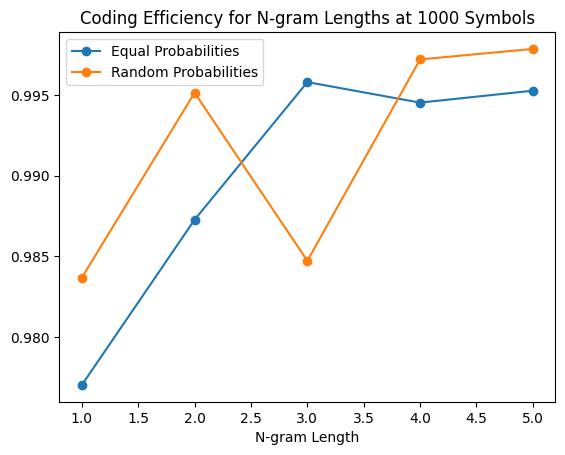

In [17]:
equal_1000_row_10symbols = equal_probs_df_10.loc[1000]
random_1000_row_10symbols = random_probs_df_10.loc[1000]

plt.plot(equal_1000_row_10symbols.index, equal_1000_row_10symbols.values, marker='o', label='Equal Probabilities')
plt.plot(random_1000_row_10symbols.index, random_1000_row_10symbols.values, marker='o', label='Random Probabilities')
plt.xlabel('N-gram Length')
plt.legend()
plt.title('Coding Efficiency for N-gram Lengths at 1000 Symbols')
None

In [18]:
alpha = 15

probs = {"A": 1 / alpha, "B": 1 / alpha, "C": 1 / alpha, "D": 1 / alpha, "E": 1 / alpha, "F": 1 / alpha, "G": 1 / alpha, "H": 1 / alpha, "I": 1 / alpha, "J": 1 / alpha, "K": 1 /alpha, "L": 1 /alpha, "M": 1 /alpha, "N": 1 /alpha, "O": 1 /alpha,}

encoder = HuffmanNGramEncoder(n=1, frequencies=probs)

print(f"Coding efficiency: {encoder.coding_efficiency}")
equal_probs_df_15 = run_experiment(probs)
print("Rows correspond to different message lengths, columns correspond to different n-gram lengths")

Coding efficiency: 0.9932772700699624
             1         2         3         4         5
10    0.993134  0.992781  0.790628  0.696581  0.994297
50    0.993200  0.992937  0.955541  0.905788  0.995746
100   0.993427  0.992932  0.964917  0.994988  0.995886
200   0.993422  0.993045  0.984486  0.995172  0.995759
500   0.993320  0.993320  0.990426  0.995113  0.995678
1000  0.993327  0.993180  0.991263  0.995032  0.995671
Rows correspond to different message lengths, columns correspond to different n-gram lengths


In [19]:
n = 15

probabilities = np.random.dirichlet(np.ones(n))

keys = [chr(ord('A') + i) for i in range(n)]

probs = dict(zip(keys, probabilities))

encoder = HuffmanNGramEncoder(n=1, frequencies=probs)

print(f"Coding efficiency: {encoder.coding_efficiency}")
random_probs_df_15 = run_experiment(probs)
print("Rows correspond to different message lengths, columns correspond to different n-gram lengths")

Coding efficiency: 0.9849396124973618
             1         2         3         4         5
10    0.984182  0.995322  0.512594  0.468823  0.998035
50    0.985166  0.995793  0.879303  0.791444  0.997675
100   0.984314  0.995642  0.896898  0.997421  0.997908
200   0.984693  0.995787  0.964003  0.997617  0.997924
500   0.985189  0.996565  0.983994  0.998297  0.998658
1000  0.985202  0.996322  0.986067  0.998183  0.998623
Rows correspond to different message lengths, columns correspond to different n-gram lengths


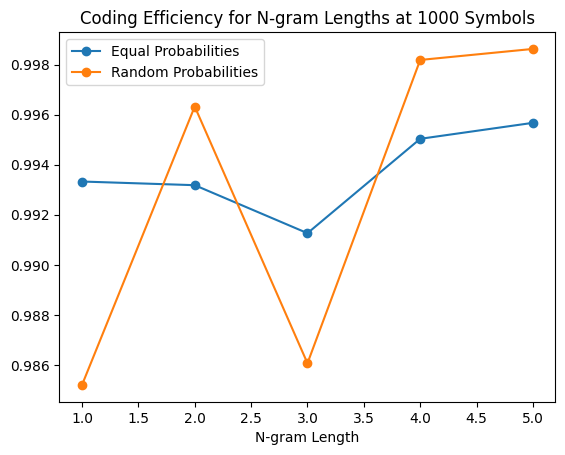

In [20]:
equal_1000_row_15symbols = equal_probs_df_15.loc[1000]
random_1000_row_15symbols = random_probs_df_15.loc[1000]

plt.plot(equal_1000_row_15symbols.index, equal_1000_row_15symbols.values, marker='o', label='Equal Probabilities')
plt.plot(random_1000_row_15symbols.index, random_1000_row_15symbols.values, marker='o', label='Random Probabilities')
plt.xlabel('N-gram Length')
plt.legend()
plt.title('Coding Efficiency for N-gram Lengths at 1000 Symbols')
None

[]

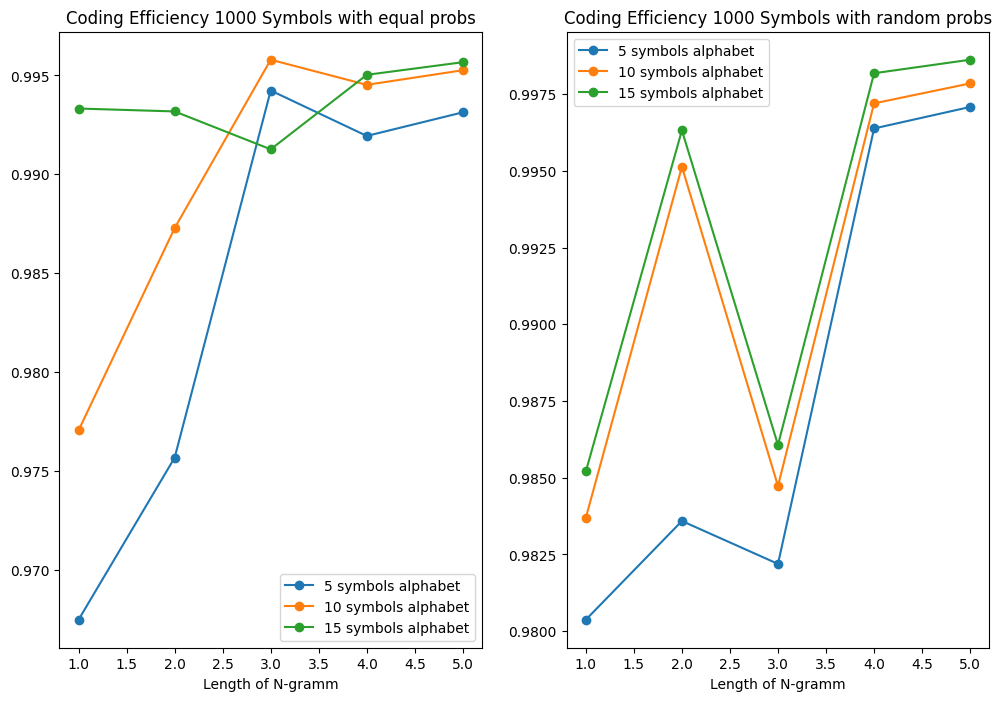

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

ax1.plot(equal_1000_row_5symbols.index, equal_1000_row_5symbols.values, marker='o', label='5 symbols alphabet')
ax1.plot(equal_1000_row_10symbols.index, equal_1000_row_10symbols.values, marker='o', label='10 symbols alphabet')
ax1.plot(equal_1000_row_15symbols.index, equal_1000_row_15symbols.values, marker='o', label='15 symbols alphabet')
ax1.set_title('Coding Efficiency 1000 Symbols with equal probs')
ax1.set_xlabel('Length of N-gramm')
ax1.legend()


ax2.plot(random_1000_row_5symbols.index, random_1000_row_5symbols.values, marker='o', label='5 symbols alphabet')
ax2.plot(random_1000_row_10symbols.index, random_1000_row_10symbols.values, marker='o', label='10 symbols alphabet')
ax2.plot(random_1000_row_15symbols.index, random_1000_row_15symbols.values, marker='o', label='15 symbols alphabet')
ax2.set_title('Coding Efficiency 1000 Symbols with random probs')
ax2.set_xlabel('Length of N-gramm')
ax2.legend()

plt.plot()

Выводы: 
1. чем больше длина сообщения тем сильнее $L(C^H_l)$ прижимается к $H_2(\mathcal{A})$ 
2. чем больше сам алфавит тем сильнее $L(C^H_l)$ прижимается к $H_2(\mathcal{A})$ 
3. между рандомными и равномерными вероятностями нет разницы
4. чем больше N-грамма тем сильнее $L(C^H_l)$ прижимается к $H_2(\mathcal{A})$ 

Минусы: 
1. Размеры алфавита растут экспоненциально, поэтому большие $N$ не подойдут, даже $N > 7$ уже много чтобы вычислять на обычном компе
2. Возникают проблемы при длине сообщения не кратной $N$ --- приходится добавлять затычки-символы # в конец неполных N-грамм чтобы декодер понимал где конец сообщения
3. Так же при добавлении символа # в Алфавит, сумма вероятностей символов становится больше $1$ --- это сказывается на кодовых словах обычных N-грамм, они могут стать длиннее, чем были бы без символа #, на больших текстах это может быть менее оптимально

### Задачи 4-5

Ща потестим реальные алфавиты с реальными частотами символов в некоторых текстах, для русского возьмем частоты из [Национального корпуса русского языка](https://ruscorpora.ru/), для английского например отсюда [English Letter Frequency](https://pi.math.cornell.edu/~mec/2003-2004/cryptography/subs/frequencies.html?spm=a2ty_o01.29997173.0.0.10995171hE2RXh)

In [22]:
eng_freq = {
    'E': 0.1202,
    'T': 0.0910,
    'A': 0.0812,
    'O': 0.0768,
    'I': 0.0731,
    'N': 0.0695,
    'S': 0.0628,
    'R': 0.0602,
    'H': 0.0592,
    'D': 0.0432,
    'L': 0.0398,
    'U': 0.0288,
    'C': 0.0271,
    'M': 0.0261,
    'F': 0.0230,
    'Y': 0.0211,
    'W': 0.0209,
    'G': 0.0203,
    'P': 0.0182,
    'B': 0.0149,
    'V': 0.0111,
    'K': 0.0069,
    'X': 0.0017,
    'Q': 0.0011,
    'J': 0.0010,
    'Z': 0.0007,
}

ru_freq = {
    'а': 0.0801,
    'б': 0.0159,
    'в': 0.0454,
    'г': 0.0170,
    'д': 0.0298,
    'е': 0.0845,
    'ё': 0.0004,
    'ж': 0.0094,
    'з': 0.0165,
    'и': 0.0735,
    'й': 0.0121,
    'к': 0.0349,
    'л': 0.0440,
    'м': 0.0321,
    'н': 0.0670,
    'о': 0.1097,
    'п': 0.0281,
    'р': 0.0473,
    'с': 0.0547,
    'т': 0.0626,
    'у': 0.0262,
    'ф': 0.0026,
    'х': 0.0097,
    'ц': 0.0048,
    'ч': 0.0144,
    'ш': 0.0073,
    'щ': 0.0036,
    'ъ': 0.0004,
    'ы': 0.0190,
    'ь': 0.0174,
    'э': 0.0032,
    'ю': 0.0064,
    'я': 0.0201,
}

In [23]:
print(sum(ru_freq.values()), sum(eng_freq.values()))

1.0001 0.9999


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

def run_big_experiment(probs: dict) -> pd.DataFrame:

    res_dict = {}
    for N in range(1, 5): # here only 4-gramm
        n_res_list = []
        for l in [10, 50, 100, 200, 500, 1000]:

            logger = PandasLogger()
            

            # Create ehncoder with binary channel alphabet
            encoder = HuffmanNGramEncoder(n=N, frequencies=probs)

            # Probabilitstic sender
            sender = ProbabilisticSender(
                encoder=encoder,
                probabilities=probs,
                message_length_range=(l, l),
                logger=logger,
                seed=42,
            )
            # Create channel
            channel = NoiselessChannel(logger=logger)
            # Create tracking receiver
            receiver = TrackingReceiver(encoder, logger=logger)

            # Create and run experiment
            runner = ExperimentRunner(sender, channel, receiver)
            result = runner.run(num_messages=1000)
            entropy = encoder.entropy
            n_res_list.append((entropy*N) / result.stats.average_code_len)
            
        res_dict[N] = n_res_list
            
    res_df = pd.DataFrame(res_dict, index=[10, 50, 100, 200, 500, 1000])
    print(res_df.head(50))
    return res_df


In [26]:
encoder = HuffmanNGramEncoder(n=1, frequencies=eng_freq)

print(f"Coding efficiency: {encoder.coding_efficiency}")
ru_probs_res = run_big_experiment(eng_freq)


Coding efficiency: 0.992784465087121
             1         2         3         4
10    0.992502  0.996518  0.557785  0.527976
50    0.995024  0.998890  0.904633  0.829568
100   0.992973  0.996419  0.913084  0.998206
200   0.992362  0.995924  0.971169  0.997541
500   0.992670  0.996336  0.986972  0.997939
1000  0.992937  0.996628  0.988468  0.998213


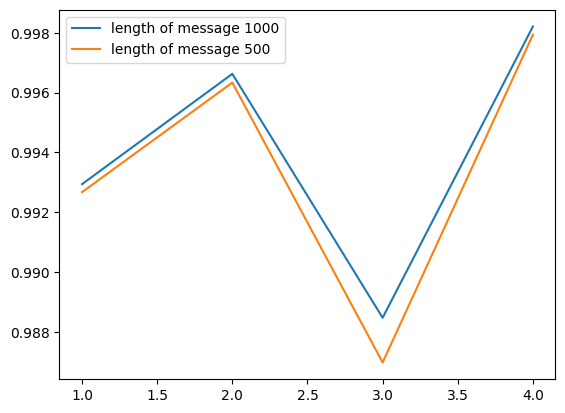

In [35]:
plt.plot(ru_probs_res.loc[1000], label="length of message 1000")
plt.plot(ru_probs_res.loc[500], label="length of message 500")
plt.legend()
None

Даже при $N \in \{1,2,3,4\}$ кодирование происходит очень долго, уже не хочется тестить на русском алфавите, впрочем даже этот график довольно репрезентативный, видно что есть рост метрики при $N=2, N=4$ но при $N=3$ есть ухудшение метрики хоть незначительное, такое ухудшение было на всех тестах, $N=3$ --- плохое значение для этого алгоритма, не знаю с чем это связано, возможно из-за того что длина сообщения не делиться на $3$ и в сообщениях всегда оставался хвост который приходилось кодировать длинными кодами с # 

В целом метрики на реальных данных и синтетических не очень сильно различаются, однако использовать этот алгоритм на реальных алфавитах размера $26,33$ неоптимально так как, прирост в метрике небольшой а жрет памяти и времени сильно больше

## Лирика: О дизайне экспериментов

Небольшое чтиво о том, как правильно спланировать эксперимент. Может помочь при решении задачи II

---

Итак, мы хотим провести некоторый эксперимент, посвященный сравнению нескольких алгоритмов: в данном случае это обычное кодирование по Хаффману и блочное кодирование алгоритмом Хаффмана — этакое экспериментальное мини-исследование. Первое с чего надо начинать любое такое экспериментальное исследование - дизайн эксперимента. Надо продумать: 
1. на какие вопросы призван ответить эксперимент;
2. какие есть факторы и переменные, влияющие на эксперимент;
3. что может повлиять на воспроизводимость результата эксперимента;
4. как интерпретировать результаты;

#### 1. Исследовательские вопросы (Research Questions)

Вольный перевод «*Research Questions*», Michael Muszynski, San José State University Writing Center

---

Исследовательский вопрос — это четкий, лаконичный и открытый вопрос, который определяет направление вашего исследования для научной работы, проекта или обзора литературы. Он составляет основу исследовательского задания и помогает направлять весь исследовательский процесс. Хорошо сформулированный исследовательский вопрос необходим для определения объема и направления вашей работы, помогая вам собирать соответствующую информацию для последующего формулирования выводов. 

**Рекомендации по формулированию хорошего исследовательского вопроса**
  
Хороший исследовательский **вопрос должен быть ясным**. Он должен содержать достаточно конкретных деталей, чтобы
аудитория могла легко его понять без дополнительных объяснений.

> *Пример неясного исследовательского вопроса*: Как окружающая среда влияет на людей?

Этот исследовательский вопрос неясен, потому что ему не хватает конкретики. Термин «окружающая среда» слишком широк и может относиться к различным средам, в которых мы живем, таким как физическая, социальная, культурная или природная. Также присутствует двусмысленность в слове «влиять»; оно довольно расплывчато. Наконец, обсуждение того, как «окружающая среда» влияет на всех «людей», слишком широко — это не тема для исследования в рамках одной работы. Без уточнения этих терминов вопросу не хватает необходимой точности для целенаправленного исследования. Чтобы исправить это, автор должен попытаться сузить свою тему.

> *Пример четко сформулированного исследовательского вопроса*: Как длительное воздействие загрязнения воздуха в городских районах
влияет на здоровье дыхательной системы взрослых в возрасте 50 лет и старше в течение пяти лет?

Кроме того, исследовательский **вопрос должен быть кратким**.

> *Пример многословного исследовательского вопроса*: Какие различные факторы (участие родителей, отношения между учителями и учениками, школьный бюджет) влияют на успеваемость учащихся в академической среде, и как они взаимодействуют друг с другом, формируя общий академический успех или неудачу учащихся в различных учебных заведениях с разным социально-экономическим положением и культурным контекстом?

Этот исследовательский вопрос не является кратким по двум основным причинам. 

1. Вопрос чрезмерно сложный, он пытается охватить множество факторов, влияющих на успеваемость учащихся, включая социально-экономическое положение, культурный контекст и учебные заведения. Чрезмерно сложный исследовательский вопрос станет проблемой, в результате чего работа будет слишком обширной для выполнения.
2. Вопрос содержит несколько подвопросов; краткий исследовательский вопрос в идеале должен содержать один центральный вопрос для сохранения ясности. Чтобы исправить это, автор может сосредоточиться на одном аспекте своего исследовательского вопроса, вместо того чтобы включать все детали.

Пример выше можно исправить следующим образом:

> *Пример краткого исследовательского вопроса*: Как участие родителей влияет на академическую успеваемость старшеклассников в городских государственных школах?

Важно быть одновременно конкретным и кратким, чтобы сформулировать целенаправленный вопрос, на который можно ответить в рамках исследовательского проекта (чтобы сделать его управляемым по объему). Наконец, исследовательский **вопрос должен быть открытым** и заслуживающим более подробного исследования/обсуждения. 

> *Пример закрытого исследовательского вопроса*: Полезна ли Khan Academy для улучшения результатов учащихся на тестах по математике?

Этот исследовательский вопрос сформулирован в бинарной форме, предполагая ответ «да» или «нет»; следовательно, у автора нет возможности подробно изучить эту тему. Чтобы исправить это, автор может рассмотреть возможность включения в свой исследовательский вопрос слов «как» или «почему», или же он может расширить свой вопрос, рассмотрев различные факторы для обсуждения или поиска измеримых путей,
например, время.

> *Пример открытого исследовательского вопроса*: Как использование студентами Khan Academy в математике улучшает понимание математических концепций с течением времени?

Использование слова «как» в начале вопроса побуждает к обсуждению и критическому мышлению. На вопросы, начинающиеся со слова «как», нельзя ответить простым «да» или «нет». В целом, создание открытого вопроса побуждает к исследованию и не ограничивает исследование бинарным результатом. Исследователям следует избегать вопросов типа «да» или «нет» и вместо этого отдавать приоритет вопросам типа «как?» или «почему?», поскольку они приведут к большему обсуждению

#### 2. Переменные эксперимента
---

Любой эксперимент оперирует набором переменных, которые можно разделить на три категории: независимые (входные), зависимые (выходные) и контролируемые. Четкое разделение этих категорий позволяет изолировать интересующие исследователя эффекты. 

- **Независимые переменные** (Independent Variables) - величины, которые исследователь намеренно изменяет, чтобы наблюдать, как они влияют на результат.
- **Зависимые переменные** (Response/Dependent Variables) - величины, которые характеризуют результат и которые, как предполгаюатся, изменяются при изменении независимых переменных.
- **Контроллируемые переменные** (Controlled variables) - величины, не являющиеся предметом интереса эксперимента, которые исследователь держит или постоянными, или сводит их влияние на эксперимент к минимуму.

Важный вид переменных - спутывающие переменные, так называемые конфаундеры (confounders). Конфаундер — переменная в статистике, которая влияет как на зависимую, так и на независимую переменные, в результате чего может быть выявлена ложная зависимость между независимой и зависимой переменной или наоборот пропущена настоящая зависимость. Спутывание — это причинная концепция, и как таковая она не может быть описана в терминах корреляций или ассоциаций. 


> Ученый изучает взаимосвязь между статусом курения (курящий против некурящего) и наличием заболеваний легких. Однако известно, что:
> 1. Потребление алкоголя и питательные привычки напрямую связаны с заболеваниями легких и общим состоянием здоровья.
> 2. Потребление алкоголя и питательные привычки влияют на здоровье независимо от статуса курения (курящий и некурящий с одинаковым потреблением алкоголя и питательными привычками могут иметь схожие риски для здоровья).
> 3. Потребление алкоголя и питательные привычки связаны со статусом курения (курящие в среднем чаще употребляют алкоголь или придерживаются менее здоровой диеты, чем некурящие).
> 4. Потребление алкоголя и питательные привычки не являются следствием самого курения (курение не обязательно приводит к увеличению потребления алкоголя или неправильному питанию, даже если они коррелируют).
>
> В этом сценарии потребление алкоголя и питательные привычки являются конфаундерами, поскольку они влияют как на независимую переменную (статус курения), так и на зависимую переменную (результат для здоровья). Если эти факторы не контролируются, наблюдаемая связь между курением и заболеваниями легких может быть частично или полностью обусловлена различиями в употреблении алкоголя или диете, а не самим курением.


**О терминологии**.
В зависимости от контекста, независимую переменную иногда называют «предикторной переменной», «регрессором», «ковариатой», «манипулируемой переменной», «объясняющей переменной», «переменной воздействия» (в теории надежности), «фактором риска» (в медицине), «признаком» (англ. «feature») или «входной переменной». Зависимая переменная иногда называется «переменной отклика», «регрессируемой переменной», «прогнозируемой переменной», «измеренной переменной», «объясняемой переменной», «экспериментальной переменной», «переменной отклика», «переменной результата», «выходной переменной», «целевой переменной» (англ. «target») или «меткой» (англ. «label»).  

Некоторые авторы предпочитают термин «объясняющая переменная» термину «независимая переменная», когда величины, рассматриваемые как независимые переменные, могут быть статистически зависимыми. Если независимая переменная называется «объясняющей переменной», то некоторые авторы предпочитают термин «переменная отклика» для зависимой переменной.


#### 3. Метрики

---

Центральным элементом любого эмпирического исследования является измерение. Чтобы сделать наблюдения количественными и допускающими статистическую проверку, исследователь должен определить используемые **метрики** — числовые характеристики, призванные отражать свойства исследуемых объектов, процессов или явлений. Метрика играет роль своеобразной линейки: с её помощью абстрактное понятие (например, «производительность алгоритма» или «удовлетворенность пользователя») переводится в конкретные числа, с которыми можно работать.

Выбор правильной метрики — задача не менее сложная, чем разработка дизайна эксперимента. От того, что именно и как измеряется, напрямую зависит, можно ли ответить на поставленный исследовательский вопрос. Метрики бывают:

- **Прямыми (direct)** — измеряют интересующее свойство непосредственно. Например, время выполнения алгоритма в секундах или количество ошибок при вводе текста.
- **Косвенными (proxy)** — используются, когда прямое измерение затруднено или невозможно. Например, количество строк кода часто используется как косвенная метрика сложности программного обеспечения, хотя напрямую его не измеряет.

При выборе метрик важно руководствоваться несколькими критериями качества. Хорошая метрика должна быть:

- **Надежной (reliable)** — давать стабильные результаты при повторных измерениях в неизменных условиях. Если при запуске одного и того же кода на одних и тех же данных мы каждый раз получаем сильно различающееся время работы (например, из-за фоновых процессов системы), такая метрика ненадежна.
- **Чувствительной (sensitive)** — способной улавливать значимые изменения в измеряемом свойстве. Метрика, которая не меняется при улучшении алгоритма, бесполезна для сравнения.
- **Интерпретируемой (interpretable)** — ее изменение должно иметь понятный смысл для исследователя и других лиц, заинтересованных в исследовании. Понятнее метрика «точность классификации 95%», чем абстрактный «коэффициент λ = 2,3».

Важно понимать, что метрики не всегда измеряют то, что мы ожидаем. Исследователь может быть уверен, что оценивает одно свойство, тогда как на деле метрика отражает нечто иное или искажает реальную картину. Это явление тесно связано с конструктной валидностью, о которой пойдет речь чуть дальше.

Классический пример — использование **количества строк кода (Lines of Code, LOC)** для измерения продуктивности программиста. Кажется логичным: чем больше кода написал разработчик, тем больше работы он сделал. На практике же высокая продуктивность часто выражается в написании *меньшего* количества строк за счет использования более эффективных конструкций или устранения избыточности. В этом случае метрика LOC измеряет не продуктивность, а скорее объем текста, который может быть обратно пропорционален качеству решения. Более подходящей для оценки продуктивности может быть метрика количество написанных строчек кода (включая те, которые были стерты). 

Другой пример — точность классификатора (accuracy) в задачах с сильным дисбалансом классов. Если исследователь разрабатывает алгоритм выявления редкого заболевания, которое встречается только у 1% пациентов, то модель, которая просто предсказывает "здоров" для всех подряд, покажет точность 99%. Блестящее число, но метрика измерит не качество алгоритма, а степень дисбаланса выборки, полностью упустив его неспособность выявлять болезнь.

Проблема усугубляется тем, что на итоговое значение метрики почти всегда влияет множество факторов, а не только исследуемая переменная. Игнорирование этого факта ведет к некорректным выводам о причинах наблюдаемого эффекта.

> Рассмотрим это на примере измерения пропускной способности веб-сервера (запросов в секунду). Исследователь может сравнивать два разных фреймворка и обнаружить, что один работает на 20% быстрее. Будет ли это означать, что он программно эффективнее? Не обязательно. На итоговое значение могли повлиять:
>
>1.  Аппаратное обеспечение: различия в частоте процессора, типе накопителя (SSD против HDD) или объеме кеш-памяти.
>2.  Сетевая инфраструктура: задержки в локальной сети или ограничения пропускной способности канала.
>3.  Версии библиотек и окружения: различия в версиях интерпретатора, компилятора, библиотек ввода-вывода или операционной системы.
>4.  Характеристики нагрузки: размер передаваемых данных, количество одновременных подключений, паттерны запросов.
>
>Таким образом, наблюдаемое различие в метрике является суммой эффектов от множества переменных. И задача исследователя — изолировать интересующий его фактор (эффективность фреймворка) от всех остальных, либо путем строгого контроля условий эксперимента, либо путем тщательного статистического анализа, разлагающего общую дисперсию на составляющие. Без такого контроля высока вероятность приписать успех не тому фактору, который его вызвал на самом деле.

#### 4. Угрозы корректности и воспроизводимость эксперимента

---

При проведении любого эмпирического исследования необходимо оценивать, насколько полученные результаты можно считать достоверными и в какой степени их можно обобщить или воспроизвести. Даже при тщательно спланированном дизайне эксперимента существует ряд факторов, способных исказить результаты или привести к неверным выводам. Такие факторы часто называют **угрозами корректности**; Такие факторы можно поделить на несколько групп:

1. Угрозы внутренней валидности — действительно ли наблюдаемый эффект вызван изменением независимой переменной?
2. Угрозы внешней валидности — насколько результаты эксперимента могут быть обобщены на другие условия, популяции или контексты?
3. Конструктная валидность — действительно ли выбранные метрики измеряют то, что мы предполагаем?

Грубо говоря внутренняя валидность это про корректность самого исследования, внешняя валидность — про то, насколько корректно обобщать результаты, а конструктная валидность — а точно ли мы померили то, что хотели?

Отдельно имеет место статистическая валидность, которая касается корректности использования статистических методов и обоснованности выводов на их основе. В частности одна из самых известных проблем в рамках статистическая валидности — использование параметрических тестов для данных, не удовлетворяющих условиям нормальности или гомоскедастичности. Другая проблема это p-hacking, но об этом как-нибудь в другой раз.

##### 3.1. Внутренняя валидность (Internal Validity)
Основные угрозы внутренней валидности включают:

- **Конфаундеры (confounders)** — наличие неучтенных переменных, которые влияют как на независимую, так и на зависимую переменную. Как было показано в примере с курением и заболеваниями легких, без контроля конфаундеров (алкоголь, диета) можно сделать ложный вывод о причинно-следственной связи. В контексте вычислительных экспериментов конфаундером может выступать, например, аппаратное обеспечение: если сравнение алгоритмов проводится на разных машинах, производительность может зависеть от скорости процессора, а не от эффективности алгоритма.
- **Эффект инструмента (instrumentation effect)** — искажения, связанные с изменением измерительного инструмента в ходе эксперимента. Для программной реализации это может означать, что разные части кода написаны с неодинаковой степенью оптимизации, что дает ложное преимущество одному из сравниваемых методов.
- **Подтверждающая ошибка (confirmation bias)** — проявляется в бессознательном подборе данных, методов анализа или интерпретации результатов таким образом, чтобы они подтверждали исходную гипотезу.
- **Систематическая ошибка отбора (selection bias)** — возникает, когда группы сравнения формируются неслучайным образом. Например, если для тестирования удобства использования продукта приглашаются только друзья исследователя, желающие его порадовать, результаты будут систематически завышены и не будут отражать мнение реальных пользователей.
- **Эффект истории (history effect)** — внешние события, происходящие между замерами, которые могут повлиять на результат. В экспериментах на производительность это могут быть например эффекты связанные с "разогревом" оборудования.

##### 3.2. Внешняя валидность (External Validity)
Примеры факторов влияющих на внешнюю валидность:

- **Репрезентативность выборки (sample representativeness)** — если тестирование проводится только на синтетических данных с простыми распределениями, выводы могут не переноситься на реальные данные со сложной структурой и взаимозависимостями.
- **Экологическая валидность (ecological validity)** — степень, в которой условия эксперимента соответствуют реальным условиям применения. Например, тестирование алгоритма сжатия на изолированном файле может не учитывать накладные расходы на хранение таблицы кодов при передаче данных по сети.
- **Эффект взаимодействия отбора и воздействия (interaction of selection and treatment)** — некоторый эффект может наблюдаться только на определенной группе и исчезать при расширении выборки. В контексте машинного обучения это известно как переобучение (overfitting) на тренировочном наборе.

##### 3.3. Конструктная валидность (Construct Validity)
Конструктная валидность связана с корректностью оперирования теоретическими понятиями.

- **Неполное определение конструкта** — например, использование только средней длины кода как метрики эффективности без учета времени кодирования и размера таблицы может дать неполную картину "качества" алгоритма.
- **Монооперационализм (mono-operation bias)** — использование единственного способа измерения сложного явления. Если мы оцениваем "удобство использования" только по опроснику без учета поведенческих метрик (времени выполнения задач, количества ошибок), мы можем упустить важные аспекты.
- **Смешение конструктов** — когда метрика отражает сразу несколько различных явлений, что затрудняет интерпретацию.


##### 3.4. Воспроизводимость (Reproducibility)

Отдельного упоминания заслуживает воспроизводимость — способность получить те же результаты при повторении эксперимента с использованием тех же методов и данных. Это фундаментальный принцип научного метода и любое хорошее исследование должно быть воспроизводимым. Угрозы воспроизводимости включают:

- **Неполная спецификация методов** — описание эксперимента пропускает важные детали реализации, без которых невозможно точное повторение.
- **Зависимость от конкретной среды** — использование специфических версий библиотек, компиляторов или операционных систем без их фиксации.
- **Отсутствие доступа к исходным данным** — если использовались проприетарные или непубличные наборы данных.
- **Стохастичность алгоритмов** — наличие случайных элементов (инициализация, перемешивание), которые не контролируются фиксацией seed-значения.

